In [1]:
import tensorflow as tf

In [4]:
mnist=tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='sigmoid'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
predictions=model(x_train[:1]).numpy()
predictions


array([[-0.73752385, -0.8475566 ,  0.03642447,  1.1806713 , -1.1804948 ,
        -0.9155967 , -1.1349635 , -0.24284185,  0.15646486, -0.85717857]],
      dtype=float32)

In [13]:
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [16]:
loss_fn(y_train[:1],predictions).numpy()

np.float32(3.068216)

In [21]:
model.compile(optimizer='adam',loss=loss_fn,metrics=['accuracy'])

In [25]:
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9687 - loss: 0.1043
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9733 - loss: 0.0908
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9753 - loss: 0.0824
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9778 - loss: 0.0746
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9799 - loss: 0.0674
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9814 - loss: 0.0614
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9814 - loss: 0.0582
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9838 - loss: 0.0527
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9848 - loss: 0.0495
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9851 - loss: 0.0468
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9868 - loss: 0.0429
Epoch 12/50
1875/1875 ━━━━━━━━

In [26]:
model.evaluate(x_test,y_test,verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.9790 - loss: 0.0922


[0.09223851561546326, 0.9789999723434448]

In [27]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [32]:
from google.colab import files

uploaded = files.upload()

Saving dogs_vs_cats_subset.zip to dogs_vs_cats_subset.zip


In [33]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/cats_dogs')

In [42]:
train_ds = create_dataset(train_paths, train_labels)
val_ds = create_dataset(val_paths, val_labels)

In [43]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(180,180,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5100 - loss: 0.7476 - val_accuracy: 0.5750 - val_loss: 0.6828
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6030 - loss: 0.6556 - val_accuracy: 0.5450 - val_loss: 0.7310
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6680 - loss: 0.5960 - val_accuracy: 0.5850 - val_loss: 0.6927
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7170 - loss: 0.5414 - val_accuracy: 0.6450 - val_loss: 0.6422
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7680 - loss: 0.4731 - val_accuracy: 0.6450 - val_loss: 0.6599
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.8130 - loss: 0.4014 - val_accuracy: 0.6550 - val_loss: 0.7446
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8840 - loss: 0.2854 - val_accuracy: 0.6950 - val_loss: 0.8209
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9230 - loss: 0.2020 - val_accuracy: 0.6900 - val_loss:

In [46]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = "/content/cats_dogs/dogs_vs_cats_subset/test/26.jpg"

img = load_img(img_path, target_size=(180,180))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Probability:", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Probability: 0.13536912
Cat 🐱


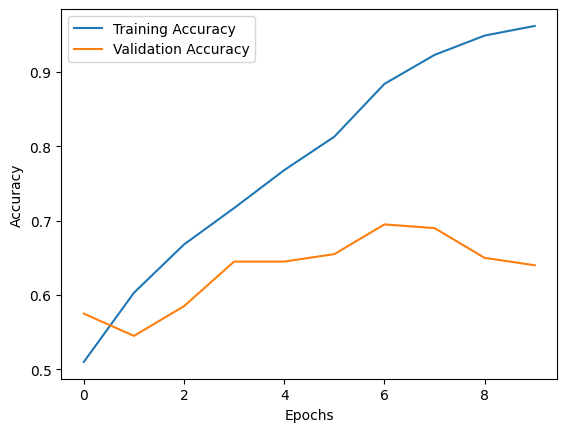

In [47]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

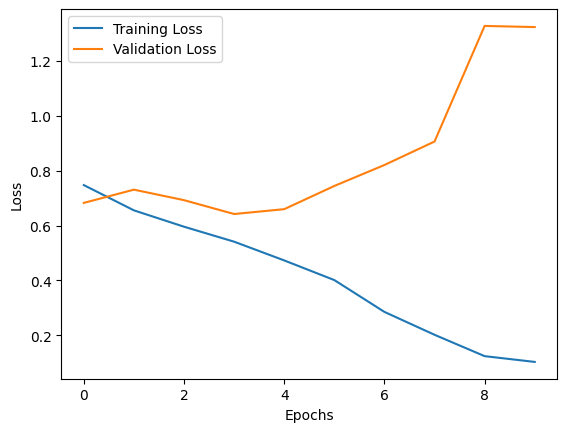

In [48]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [49]:
model.save('/content/cats_dogs_model.keras')

In [50]:
model = tf.keras.models.load_model('/content/cats_dogs_model.keras')

In [51]:
import os

test_folder = "/content/cats_dogs/dogs_vs_cats_subset/test"

for file in os.listdir(test_folder)[:10]:
    img_path = os.path.join(test_folder, file)

    img = load_img(img_path, target_size=(180,180))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]

    print(file, "→", "Dog" if pred >= 0.5 else "Cat",
          "| Probability:", round(float(pred), 3))

26.jpg → Cat | Probability: 0.135
48.jpg → Dog | Probability: 0.983
36.jpg → Cat | Probability: 0.37
99.jpg → Cat | Probability: 0.26
82.jpg → Cat | Probability: 0.305
57.jpg → Dog | Probability: 0.992
59.jpg → Dog | Probability: 0.999
73.jpg → Dog | Probability: 1.0
50.jpg → Cat | Probability: 0.011
95.jpg → Dog | Probability: 0.998


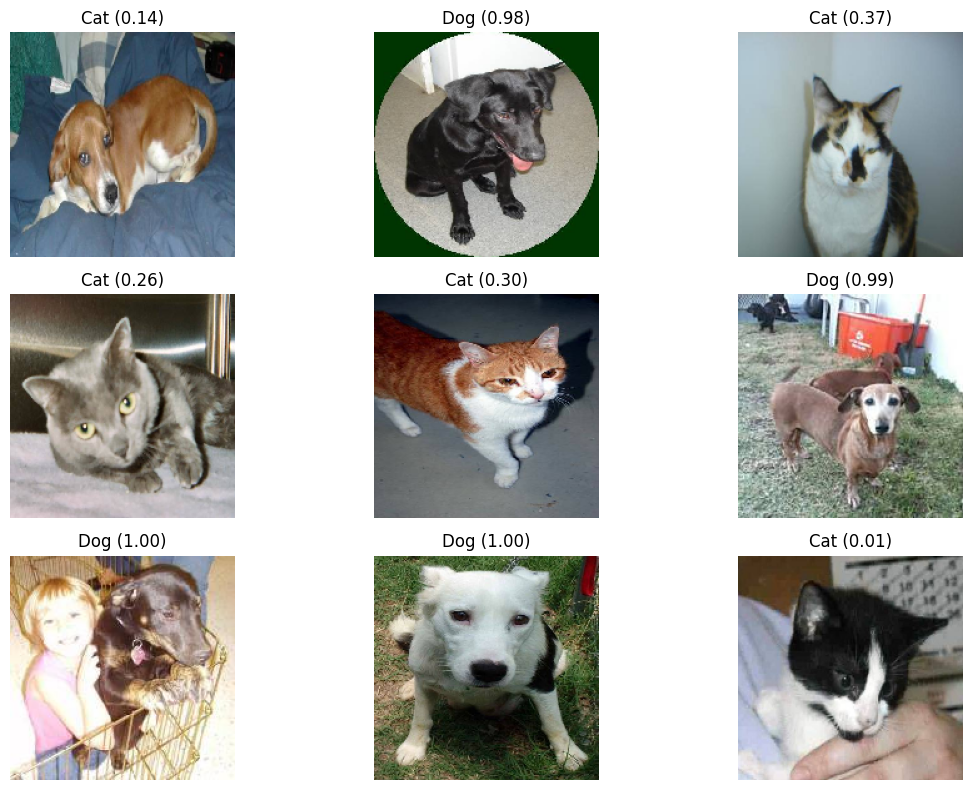

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, file in enumerate(os.listdir(test_folder)[:9]):
    img_path = os.path.join(test_folder, file)

    img = load_img(img_path, target_size=(180,180))
    img_array = img_to_array(img) / 255.0

    pred = model.predict(
        np.expand_dims(img_array, axis=0),
        verbose=0
    )[0][0]

    label = "Dog" if pred >= 0.5 else "Cat"

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"{label} ({pred:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
model.save("/content/cats_dogs_model.keras")

In [54]:
import os

print(os.path.exists("/content/cats_dogs_model.keras"))

True


In [55]:
import os

print(os.path.exists("/content/cats_dogs_model.keras"))

True


In [56]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.6400 - loss: 1.3237
Validation Accuracy: 0.6399999856948853
Validation Loss: 1.323706030845642


In [57]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions >= 0.5).astype(int).flatten())

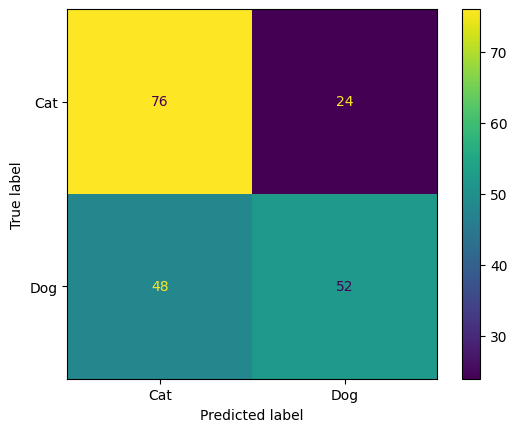

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()
plt.show()

In [59]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       0.61      0.76      0.68       100
         Dog       0.68      0.52      0.59       100

    accuracy                           0.64       200
   macro avg       0.65      0.64      0.63       200
weighted avg       0.65      0.64      0.63       200



In [60]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [61]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(180,180,3)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [63]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5340 - loss: 0.6935 - val_accuracy: 0.5550 - val_loss: 0.6846
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5990 - loss: 0.6660 - val_accuracy: 0.6550 - val_loss: 0.6433
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6320 - loss: 0.6430 - val_accuracy: 0.6800 - val_loss: 0.6337
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6650 - loss: 0.6054 - val_accuracy: 0.6250 - val_loss: 0.6248
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.6510 - loss: 0.6289 - val_accuracy: 0.6900 - val_loss: 0.6021


In [64]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 356ms/step - accuracy: 0.6900 - loss: 0.6021
Validation Accuracy: 0.6899999976158142
Validation Loss: 0.6020982265472412


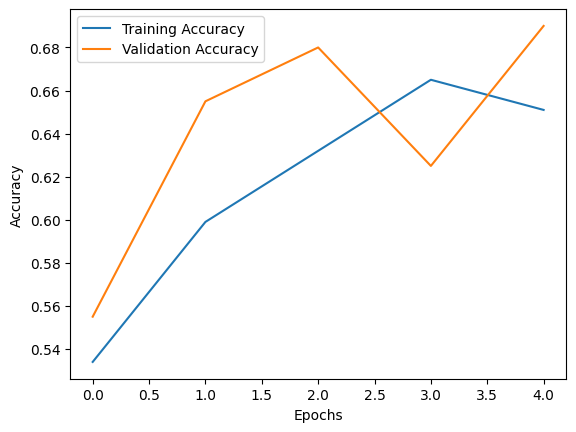

In [65]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

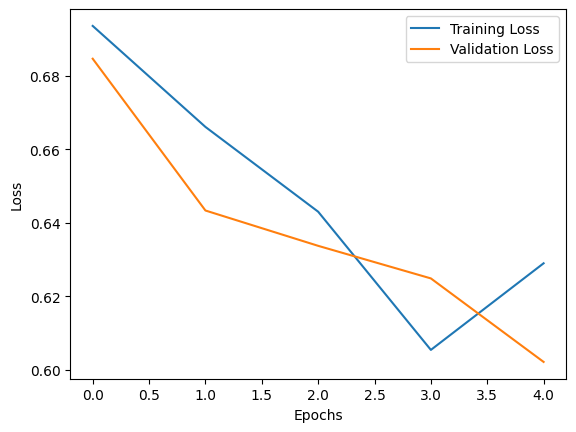

In [66]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [68]:
model.save("/content/cats_dogs_model_augmented.keras")